<a href="https://colab.research.google.com/github/hubcborja/Trabajo_grado_ECIJG/blob/main/Graficacion_red_convenios_Doble_Tributacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [6]:
base_convenios=pd.read_csv('https://raw.githubusercontent.com/hubcborja/Trabajo_grado_ECIJG/refs/heads/main/bases_datos/convenios_tributarios.csv?token=GHSAT0AAAAAADN3IWBA4RNYP64FUAUL6JR42IY77FA')
base_convenios.head()

,Country A,Country B,Type,Date of signature,Effective,Status,Source,WHTrates,PE,Other,...,12(2)E,12(A),13(4),13(5),14,16(2),21(3),25B(5),27,29
0,Albania,Israel,Original,2021,2022.0,In Force,0.30,0.31,0.45,0.13,...,5,0,YES,NO,NO,NO,NO,NO,NO,PPT
1,Albania,Turkey,Original,1994,1997.0,In Force,0.19,0.38,0.06,0.13,...,10,0,NO,NO,YES,NO,NO,NO,NO,NaN
2,Albania,Romania,Original,1994,1995.0,In Force,0.47,0.47,0.58,0.38,...,15,0,NO,NO,YES,NO,YES,NO,NO,NaN
3,Albania,Italy,Original,1994,2000.0,In Force,0.19,0.25,0.19,0.13,...,5,0,NO,NO,YES,NO,NO,NO,NO,NaN
4,Albania,Russia,Original,1995,1998.0,In Force,0.23,0.38,0.06,0.25,...,10,0,NO,NO,YES,NO,YES,NO,NO,NaN


In [7]:
base_convenios.columns

Index(['Country A', 'Country B', 'Type', 'Date of signature', 'Effective',
       'Status', 'Source', 'WHTrates', 'PE', 'Other', 'UN', '5(3)(a)C',
       '5(3)(a)S', '5(3)(b)', '5(4)(a)', '5(4)(b)', '5(5)(b)', '5(6)', '5(7)',
       '7(1)(b&c)', '7(3)', '8(2)', '10(2)(a)Q', '10(2)(a)T', '10(2)(b)',
       '11(2)', '11(2)F', '12(2)', '12(2)C', '12(2)E', '12(A)', '13(4)',
       '13(5)', '14', '16(2)', '21(3)', '25B(5)', '27', '29'],
      dtype='object')

In [8]:
G = nx.from_pandas_edgelist(base_convenios,
                            source='Country A',
                            target='Country B',
                            edge_attr='Date of signature')

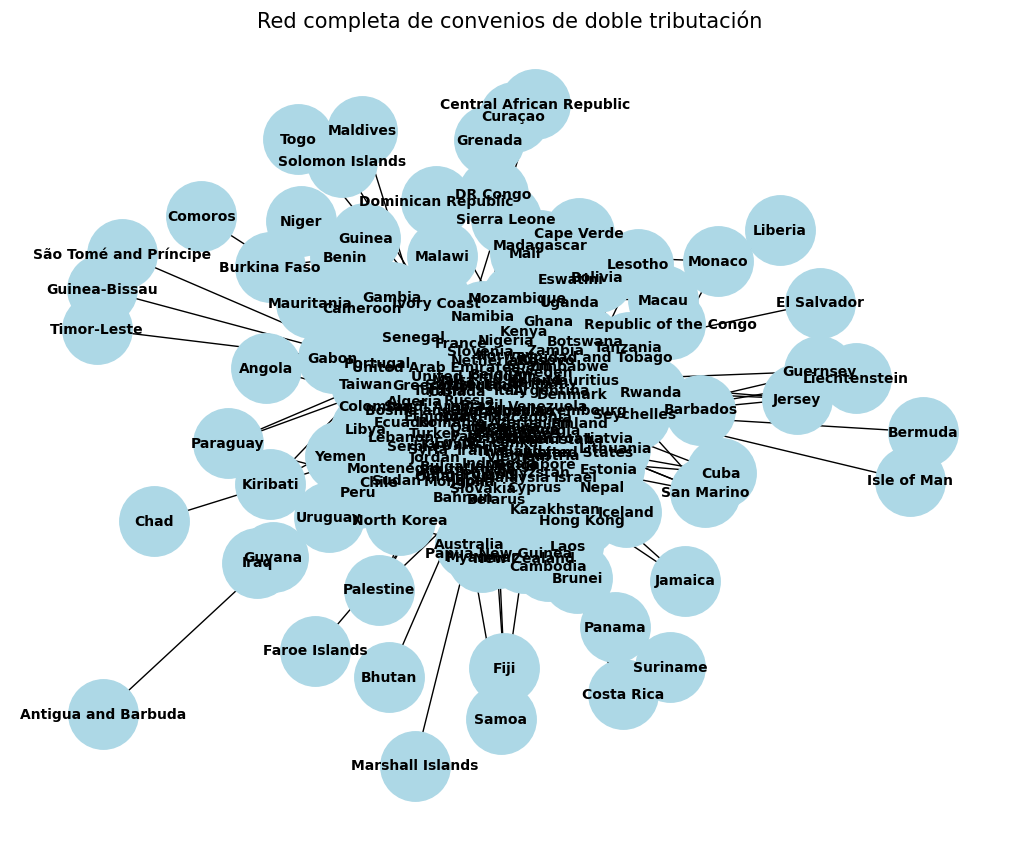

In [9]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=10, font_weight='bold')
plt.title("Red completa de convenios de doble tributación", size=15)
plt.show()

In [71]:
# Lista de nodos para el subgrafo
paises_subgrafo = ['Colombia', 'United States', 'Panama', 'China', 'India', 'Brazil', 'Ecuador', 'Netherlands', 'Mexico', 'Turkey',
                   'Chile', 'Peru', 'Spain', 'Italy', 'South Korea', 'Canada', 'Germany', 'Venezuela', 'Dominican Republic',
                   'Belgium']

# Crear el subgrafo
subgrafo = G.subgraph(paises_subgrafo)


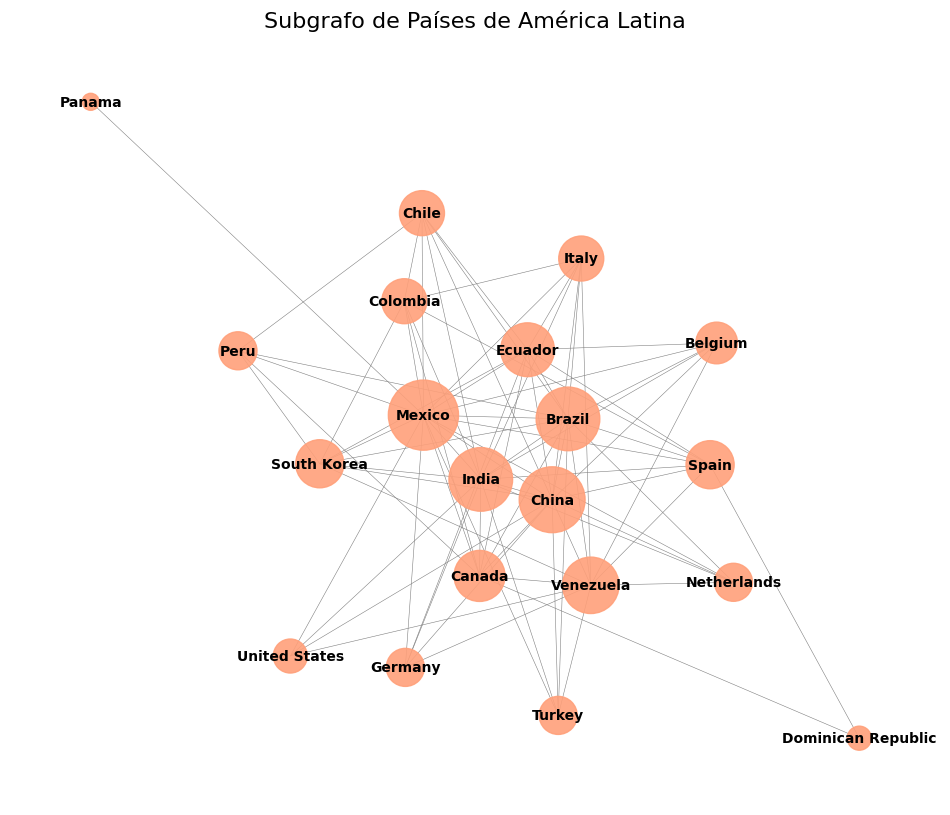

In [72]:
node_degrees = dict(subgrafo.degree())
# Escalar los tamaños: Multiplica por un factor para que sean visualmente distintos
node_sizes = [v * 150 for v in node_degrees.values()]


# 2. AJUSTAR EL LAYOUT (Aumentar la Repulsión)
# k=0.35 a k=0.5 suele funcionar bien para separar nodos densos
pos = nx.spring_layout(subgrafo, k=0.4, iterations=50, seed=42)


# 3. DIBUJAR CON ESTILOS MEJORADOS
plt.figure(figsize=(12, 10))

# Nodos: Tamaño por Grado, Color por Continente/Grupo de interés (ej. rojo para LATAM)
nx.draw_networkx_nodes(
    subgrafo, pos,
    node_size=node_sizes,
    node_color='lightsalmon',  # Color más suave
    alpha=0.9
)

# Enlaces: Reducir grosor y opacidad para mayor claridad
nx.draw_networkx_edges(
    subgrafo, pos,
    width=0.4,  # Grosor muy delgado
    alpha=1,  # Opacidad baja
    edge_color='gray'
)

# Etiquetas: Texto más claro
nx.draw_networkx_labels(
    subgrafo, pos,
    font_size=10,
    font_weight='bold',
    font_color='black'
)

plt.title("Subgrafo de Países de América Latina", fontsize=16)
plt.axis('off') # Ocultar los ejes
plt.show()

In [11]:
# Obtener una lista de todos los años únicos de las aristas
anios = [int(d['Date of signature']) for u, v, d in G.edges(data=True)]

# Crear una paleta de colores (colormap)
# Puedes elegir cualquier mapa de colores de Matplotlib, como 'viridis', 'plasma', 'cividis', etc.
cmap = cm.get_cmap('plasma')

# Normalizar los años para que se ajusten al rango del colormap (0 a 1)
min_anio = min(anios)
max_anio = max(anios)
norm = plt.Normalize(vmin=min_anio, vmax=max_anio)
colores_aristas = [cmap(norm(anio)) for anio in anios]

/tmp/ipython-input-1542449225.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

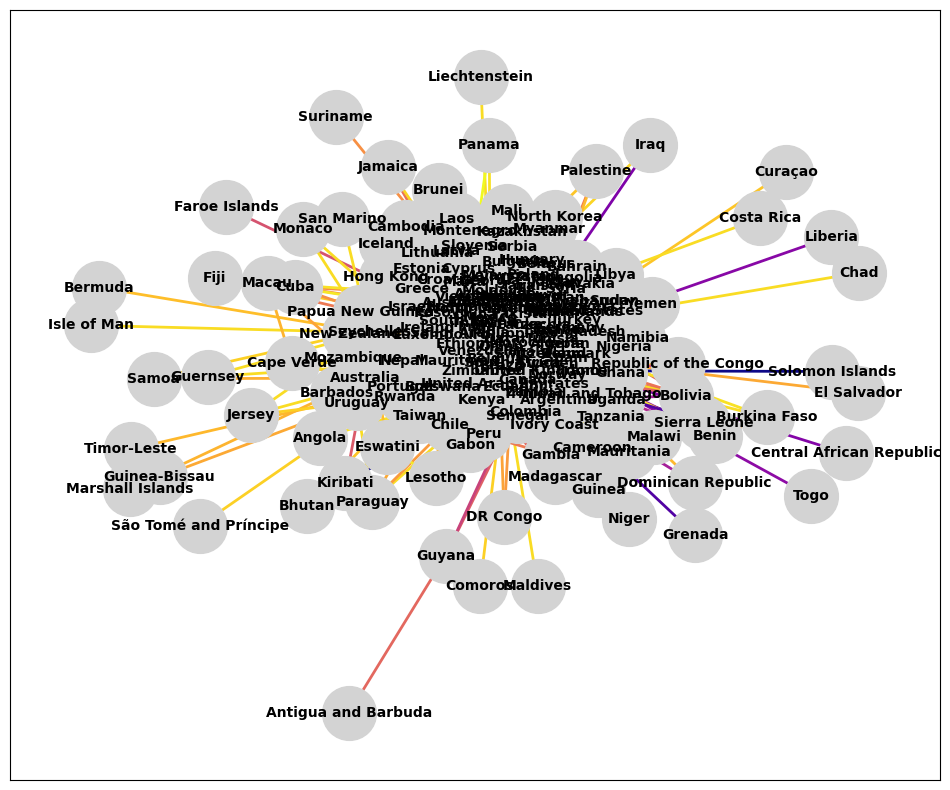

In [12]:
plt.figure(figsize=(12, 10))

# Definir la posición de los nodos
pos = nx.spring_layout(G)

# Dibujar los nodos y sus etiquetas
nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Dibujar las aristas con los colores asignados
# Es crucial que el orden de edge_color coincida con el de la lista G.edges()
aristas_sorted = list(G.edges(data=True))
colores_aristas_sorted = [cmap(norm(int(d['Date of signature']))) for u, v, d in aristas_sorted]
nx.draw_networkx_edges(G, pos, edgelist=aristas_sorted, edge_color=colores_aristas_sorted, width=2)

# Crear la barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Necesario para que funcione el colorbar
cbar = plt.colorbar(sm, orientation='vertical', shrink=0.7)
cbar.set_label('Año de la firma del convenio')

plt.title("Red de convenios por año de firma", size=15)
plt.axis('off')
plt.show()

# Subgrafo paises vecinos de Colombia

Este grafo representa aquellos paises cercanos a Colombia y los acuerdos para evitar la doble tributación que tienen con otros paises

In [40]:
base_convenios['Country A'].unique().size

166

In [47]:
base_convenios=pd.read_csv('https://raw.githubusercontent.com/hubcborja/Trabajo_grado_ECIJG/refs/heads/main/bases_datos/convenios_tributarios.csv?token=GHSAT0AAAAAADN3IWBB2QDWQXQMYSLCQZY42IZJFSQ')
# base_convenios.head()


G = nx.from_pandas_edgelist(base_convenios,
                            source='Country A',
                            target='Country B')

nodo_principal = 'Colombia'

# Verificar que el nodo exista en el grafo
if nodo_principal not in G:
    print(f"Error: El nodo '{nodo_principal}' no existe en el grafo actual.")
else:
    # --- VECINOS DE PRIMER ORDEN (Grado 1) ---
    # Los vecinos directos son los países con los que Colombia tiene un CDT
    vecinos_primer_orden = set(G.neighbors(nodo_principal))

    print(f"--- Vecinos de Primer Orden de {nodo_principal} ---")
    print(f"Total: {len(vecinos_primer_orden)}")
    print(vecinos_primer_orden)


    # --- VECINOS DE SEGUNDO ORDEN (Grado 2) ---
    # Los vecinos de los vecinos directos (excluyendo a Colombia misma)
    vecinos_segundo_orden = set()

    # Iterar sobre cada vecino de primer orden
    for vecino in vecinos_primer_orden:
        # Obtener los vecinos del vecino actual
        vecinos_segundo_orden.update(G.neighbors(vecino))

    # Excluir los vecinos de primer orden y el nodo principal (COL)
    vecinos_segundo_orden = vecinos_segundo_orden - vecinos_primer_orden
    vecinos_segundo_orden.discard(nodo_principal) # Aseguramos que Colombia no esté en la lista


    print("\n--- Vecinos de Segundo Orden de COL (Excluyendo vecinos de Grado 1) ---")
    print(f"Total: {len(vecinos_segundo_orden)}")
    print(vecinos_segundo_orden)

--- Vecinos de Primer Orden de Colombia ---
Total: 13
{'South Korea', 'Switzerland', 'Japan', 'France', 'Spain', 'Canada', 'Italy', 'India', 'Mexico', 'United Kingdom', 'Portugal', 'Chile', 'Czechia'}

--- Vecinos de Segundo Orden de COL (Excluyendo vecinos de Grado 1) ---
Total: 140
{'Vietnam', 'Faroe Islands', 'Azerbaijan', 'Jordan', 'Mauritius', 'Cambodia', 'Uzbekistan', 'Morocco', 'Kazakhstan', 'Lithuania', 'Lesotho', 'Kenya', 'Moldova', 'Bangladesh', 'Tajikistan', 'Bulgaria', 'Romania', 'Sweden', 'Russia', 'Angola', 'Taiwan', 'Cape Verde', 'Kiribati', 'Israel', 'Guinea-Bissau', 'Ghana', 'Malta', 'Slovakia', 'Solomon Islands', 'Netherlands', 'Zambia', 'Eswatini', 'Ethiopia', 'Laos', 'Costa Rica', 'Cyprus', 'Ivory Coast', 'Gambia', 'Bahrain', 'Albania', 'Ukraine', 'Mozambique', 'Armenia', 'Bolivia', 'Germany', 'Peru', 'Mali', 'Iran', 'Libya', 'Belarus', 'Central African Republic', 'Latvia', 'Hungary', 'Montenegro', 'Panama', 'Jamaica', 'Timor-Leste', 'Indonesia', 'Togo', 'Greece', '

In [48]:
nodos_interes={nodo_principal} | vecinos_primer_orden
nodos_interes=nodos_interes | vecinos_segundo_orden

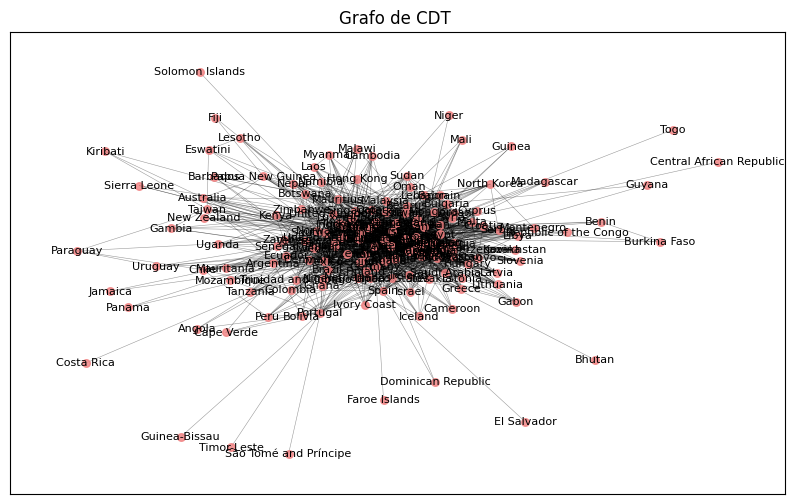

In [50]:
# Crear el subgrafo
subgrafo = G.subgraph(nodos_interes)
# 1. Calcular métrica para tamaño (ej. Degree)
node_degrees = dict(G.degree())
# Escalar el tamaño para la visualización
node_sizes = [v * 50 for v in node_degrees.values()]

# 2. Generar el layout
pos = nx.spring_layout(G)
plt.figure(figsize=(10, 6))
# 3. Dibujar el grafo
nx.draw_networkx_nodes(
    subgrafo, pos,
    node_size=30,
    node_color='lightcoral', # Cambiar color
    alpha=0.8
)
nx.draw_networkx_edges(
    subgrafo, pos,
    width=0.4,  # grosor
    alpha=0.4 #opacidad
)

nx.draw_networkx_labels(subgrafo, pos, font_size=8)
plt.title("Grafo de CDT ")
plt.show()

In [51]:
metrics = {}

metrics['Degree'] = dict(subgrafo.degree())
metrics['ClosenessCentrality'] = nx.closeness_centrality(subgrafo)
metrics['BetweennessCentrality'] = nx.betweenness_centrality(subgrafo)
metrics['ClusteringCoefficient'] = nx.clustering(subgrafo)
metrics['Eccentricity'] = nx.eccentricity(subgrafo)
metrics['NeighborhoodConnectivity'] = nx.average_neighbor_degree(subgrafo)
metrics['Stress'] = nx.load_centrality(subgrafo)

# --- Métricas Globales (No por nodo, sino para la red completa) ---
try:
    avg_path = nx.average_shortest_path_length(subgrafo)
    print(f"AverageShortestPathLength: {avg_path}")
except nx.NetworkXError:
    # Esto ocurre si la red no está conectada (importante para tu tesis!)
    print("La red no está conectada, no se puede calcular ASPL.")

# --- Métricas Simples y de Estructura ---
print(f"NumberOfUndirectedEdges: {subgrafo.number_of_edges()}")
print(f"SelfLoops: {nx.number_of_selfloops(subgrafo)}")

# --- Conversión a DataFrame para integrar con atributos de nodo (OE2) ---
df_metrics = pd.DataFrame(metrics)
# El índice del DataFrame son los países (nodos)

print("\nDataFrame de Métricas Estructurales (Primeras filas):")
df_metrics.head()

AverageShortestPathLength: 2.017400899753841
NumberOfUndirectedEdges: 1903
SelfLoops: 0

DataFrame de Métricas Estructurales (Primeras filas):


,Degree,ClosenessCentrality,BetweennessCentrality,ClusteringCoefficient,Eccentricity,NeighborhoodConnectivity,Stress
Albania,43,0.570896,0.006831,0.234773,3,35.930233,0.006922
Israel,17,0.488818,0.000245,0.500000,3,59.470588,0.000245
Turkey,36,0.538732,0.004301,0.352381,3,48.222222,0.004247
Romania,37,0.538732,0.003362,0.348348,3,47.513514,0.003359
Italy,46,0.560440,0.009328,0.241546,3,41.478261,0.009275


In [52]:
jaccard_scores = nx.jaccard_coefficient(subgrafo)

# 3. Almacenar los resultados en una lista o DataFrame
scores_list = []
for u, v, p in jaccard_scores:
    # 'p' es la probabilidad/puntuación de Jaccard
    scores_list.append({'Pais_i': u, 'Pais_j': v, 'Jaccard_Score': p})

df_jaccard = pd.DataFrame(scores_list)
df_jaccard.sort_values(by=['Pais_i','Jaccard_Score'], ascending=[True, False], inplace=True)

In [53]:
df_jaccard[df_jaccard['Pais_i']=='Colombia']

,Pais_i,Pais_j,Jaccard_Score
5542,Colombia,Ecuador,0.375000
5612,Colombia,Trinidad and Tobago,0.333333
5611,Colombia,Brazil,0.324324
5572,Colombia,Argentina,0.307692
5567,Colombia,Senegal,0.304348
...,...,...,...
5545,Colombia,United Arab Emirates,0.033333
5615,Colombia,Serbia,0.031250
5623,Colombia,Croatia,0.030303
5579,Colombia,Belarus,0.025641


In [55]:
nodo_colombia='Colombia'

aa_scores_generator = nx.adamic_adar_index(subgrafo)

# 2. Convertir el generador en un DataFrame para análisis
scores_list = []
for u, v, score in aa_scores_generator:
    scores_list.append({
        'Pais_A': u,
        'Pais_B': v,
        'Adamic_Adar_Score': score
    })

df_adamic_adar = pd.DataFrame(scores_list)

# 3. Filtrar para ver solo las predicciones de Colombia
df_colombia_aa = df_adamic_adar[
    (df_adamic_adar['Pais_A'] == nodo_colombia) |
    (df_adamic_adar['Pais_B'] == nodo_colombia)
]

# 4. Ordenar para ver los países con mayor probabilidad de firmar un CDT
df_colombia_aa_sorted = df_colombia_aa.sort_values(
    by='Adamic_Adar_Score',
    ascending=False
)

print(f"--- Top 5 Países Candidatos para CDT con {nodo_colombia} (Según Adamic-Adar) ---")
df_colombia_aa_sorted

--- Top 5 Países Candidatos para CDT con Colombia (Según Adamic-Adar) ---


,Pais_A,Pais_B,Adamic_Adar_Score
5571,Colombia,South Africa,3.593753
5576,Colombia,China,3.593753
5611,Colombia,Brazil,3.347475
4610,Ukraine,Colombia,3.176721
5591,Colombia,Indonesia,3.176721
...,...,...,...
5583,Colombia,Montenegro,0.217147
5584,Colombia,Bhutan,0.217147
5615,Colombia,Serbia,0.217147
5623,Colombia,Croatia,0.217147
